# EcoPackAI making 

In [1]:
import sys
print(sys.executable)


c:\Users\Rajan\OneDrive\Desktop\CODING\jbooks\EcoPackAI\.venv\Scripts\python.exe


### Libraries import

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


### Loading the csv file

In [3]:
# Load dataset
df = pd.read_csv("materials_backup_v3.csv")

# Quick preview
df.head()


,material_id,material_name,strength,weight_capacity,cost,biodegradability_score,co2_score,recyclability_percentage
0,1,Thin Paper,1,2.0,2,10,1,100
1,2,Starch Film,1,3.0,2,10,1,90
2,3,Light Foam,1,2.5,3,9,2,80
3,4,Tissue Paper,1,1.5,2,10,1,95
4,5,Corn Peanuts,1,2.0,3,10,2,10


### Classifying the features and Targes

In [4]:
# Features (X)
X = df[['strength',
        'weight_capacity',
        'biodegradability_score',
        'recyclability_percentage']]

# Targets (y)
y_cost = df['cost']
y_co2 = df['co2_score']


### Spliting the dataset into 80% training and 20% testing

In [5]:
X_train, X_test, y_cost_train, y_cost_test, y_co2_train, y_co2_test = train_test_split(
    X, y_cost, y_co2,
    test_size=0.2,
    random_state=42
)


In [6]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_cost_train:", y_cost_train.shape)
print("y_co2_train:", y_co2_train.shape)


X_train: (36, 4)
X_test: (9, 4)
y_cost_train: (36,)
y_co2_train: (36,)


### Scale the dataset

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
print("Mean:", np.mean(X_train_scaled, axis=0))
print("Std:", np.std(X_train_scaled, axis=0))


Mean: [-1.11022302e-16 -1.85037171e-17 -1.09480326e-16  3.85494106e-16]
Std: [1. 1. 1. 1.]


### Randomforest model for cost prediction

In [9]:
rf_cost = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_cost.fit(X_train_scaled, y_cost_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [10]:
y_cost_pred = rf_cost.predict(X_test_scaled)


### Evaluation of Randomforest model

In [11]:
mae_cost = mean_absolute_error(y_cost_test, y_cost_pred)
rmse_cost = np.sqrt(mean_squared_error(y_cost_test, y_cost_pred))
r2_cost = r2_score(y_cost_test, y_cost_pred)

print("Cost MAE:", mae_cost)
print("Cost RMSE:", rmse_cost)
print("Cost R2:", r2_cost)


Cost MAE: 0.5788888888888889
Cost RMSE: 0.7784243344374868
Cost R2: 0.8708381578947368


### XGBoost model for co2 prediction

In [12]:
xgb_co2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_co2.fit(X_train_scaled, y_co2_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [13]:
y_co2_pred = xgb_co2.predict(X_test_scaled)


### Evaluation of XGBoost model

In [14]:
mae_co2 = mean_absolute_error(y_co2_test, y_co2_pred)
rmse_co2 = np.sqrt(mean_squared_error(y_co2_test, y_co2_pred))
r2_co2 = r2_score(y_co2_test, y_co2_pred)

print("CO2 MAE:", mae_co2)
print("CO2 RMSE:", rmse_co2)
print("CO2 R2:", r2_co2)


CO2 MAE: 0.4326140582561493
CO2 RMSE: 0.6520309383520483
CO2 R2: 0.9460240006446838


### Feature Importance – Cost Model

In [15]:
import pandas as pd

feature_importance = pd.Series(
    rf_cost.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


weight_capacity             0.742145
strength                    0.207344
recyclability_percentage    0.028244
biodegradability_score      0.022267
dtype: float64

In [16]:
print(y_cost_train.head())

3     2
6     3
24    5
32    7
19    6
Name: cost, dtype: int64


In [17]:
print(X_train_scaled.mean())

4.3175339846533866e-17


## Making Rank System
### Verified Raw Data

In [18]:
df.head()


,material_id,material_name,strength,weight_capacity,cost,biodegradability_score,co2_score,recyclability_percentage
0,1,Thin Paper,1,2.0,2,10,1,100
1,2,Starch Film,1,3.0,2,10,1,90
2,3,Light Foam,1,2.5,3,9,2,80
3,4,Tissue Paper,1,1.5,2,10,1,95
4,5,Corn Peanuts,1,2.0,3,10,2,10


### Normalized Cost & CO₂

In [19]:
# Normalize cost
cost_norm = (df['cost'] - df['cost'].min()) / (df['cost'].max() - df['cost'].min())

# Normalize CO2 (low is good, so invert)
co2_norm = (df['co2_score'] - df['co2_score'].min()) / (df['co2_score'].max() - df['co2_score'].min())


### Created Suitability Score

In [20]:
df['suitability'] = (
    df['biodegradability_score'] / 10 +
    df['recyclability_percentage'] / 100
) / 2


### Applied Weighted Final Score

In [21]:
df['final_score'] = (
    0.4 * cost_norm +
    0.4 * co2_norm +
    0.3 * df['suitability']
)


### Ranked Materials

In [22]:
ranked_materials = df.sort_values('final_score').reset_index(drop=True)
ranked_materials[['material_name', 'final_score']]


,material_name,final_score
0,Corn Peanuts,0.272143
1,Starch Film,0.285000
2,Tissue Paper,0.292500
3,Thin Paper,0.300000
4,Leaf Wrap,0.300000
5,Potato Starch,0.300000
6,Rice Paper,0.320000
7,Thin Bio-Bag,0.332143
8,Recycled Newsprint,0.355000
9,Seaweed Film,0.357143


### Sorting Materials by Final Score

In [23]:
ranked_materials = df.sort_values('final_score')


### Extracting Material Names & Scores

In [24]:
materials = ranked_materials['material_name']
scores = ranked_materials['final_score']


### Automatically Selecting Best Material

In [25]:
best_material = ranked_materials.iloc[0]
print("Best Material:", best_material['material_name'])
print("Final Score:", best_material['final_score'])


Best Material: Corn Peanuts
Final Score: 0.27214285714285713


### Visualized with Graph

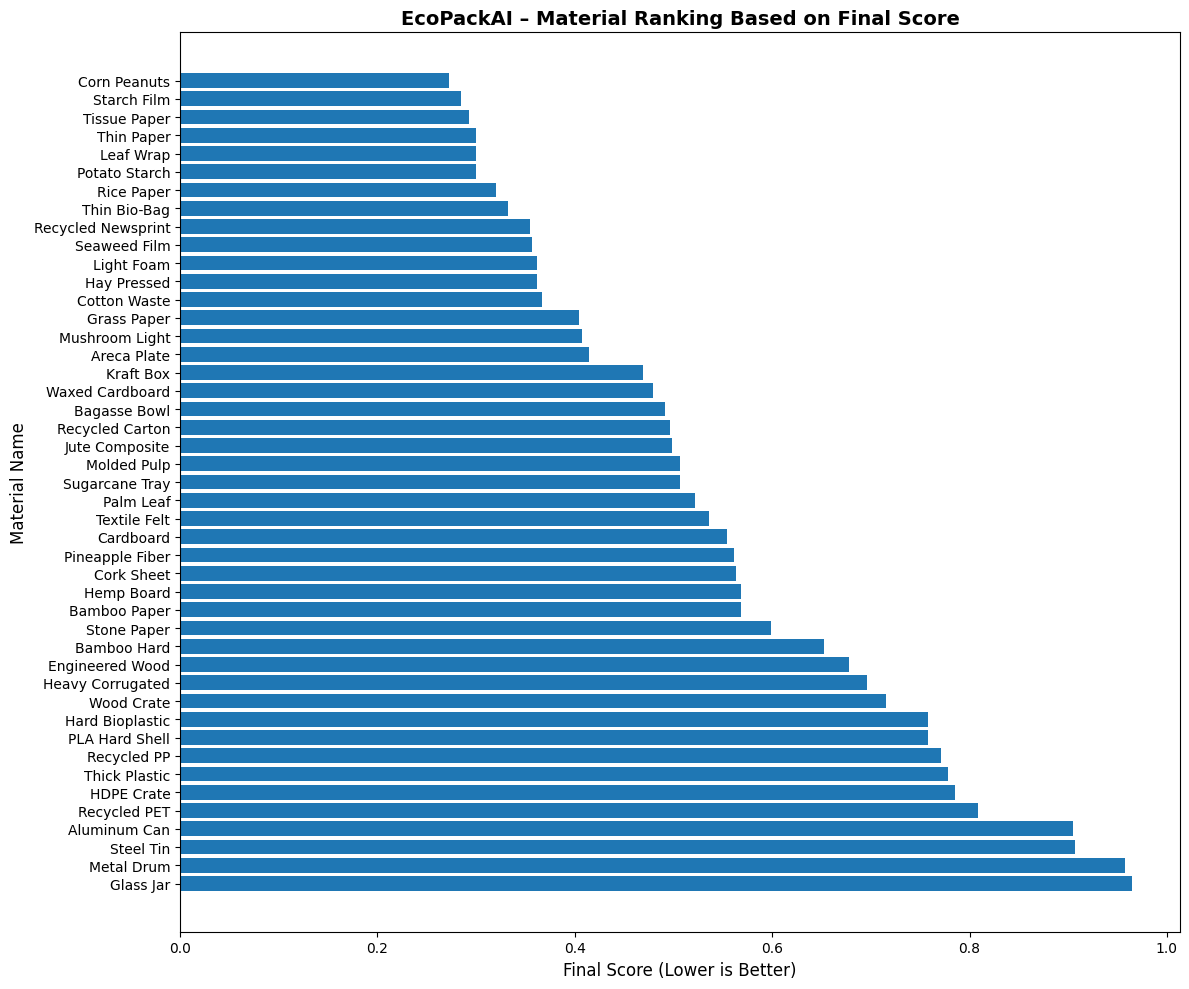

In [26]:
import matplotlib.pyplot as plt

# Make sure data is sorted (already should be)
ranked = ranked_materials.copy()

materials = ranked['material_name']
scores = ranked['final_score']

plt.figure(figsize=(12, 10))  # Bigger canvas

plt.barh(materials, scores)  # Horizontal bar chart

plt.xlabel("Final Score (Lower is Better)", fontsize=12)
plt.ylabel("Material Name", fontsize=12)
plt.title("EcoPackAI – Material Ranking Based on Final Score", fontsize=14, fontweight='bold')

plt.gca().invert_yaxis()  # Best material on TOP

plt.tight_layout()
plt.show()


In [27]:
import joblib

joblib.dump(rf_cost, "rf_cost_model.pkl")
joblib.dump(xgb_co2, "xgb_co2_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']